# Day 3: 再訓練による検証 — 60サンプル vs 300サンプル

**日付**: 2026-03-01  
**目的**: 「訓練データ60サンプルでは少なすぎるのでは？」という疑問に対する定量的回答

## このノートブックで検証すること

1. **全体比較**: FG-ARI, Metal ARI, Rubber ARI の平均値は変わるか？
2. **対応のある t 検定**: 同一シーンでのペア比較（教育的解説つき）
3. **シーンタイプ別分析**: metal_only / rubber_only / mixed での差異
4. **Train-test overlap 問題**: データリークがあっても勝てないという論点
5. **材質比率の確認**: 訓練データの構成が結果に影響しうるか

## 実験設定

| | 60-sample モデル（旧） | 300-sample モデル（新） |
|---|---|---|
| 訓練データ | `movi_a_subset/` (60 files) | `movi_a_v2/` (300 files) |
| 評価データ | `movi_a_v2/` (300 files) | `movi_a_v2/` (300 files) |
| backbone | DINOv2 ViT-S/14 | DINOv2 ViT-S/14 |
| epochs | 200 | 200 |
| batch_size | 2 | 16 |
| その他 | lr=0.001, slots=5, τ=0.5, mse | 同左 |

In [16]:
# §1 ライブラリ読み込み & データ準備
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from pathlib import Path

matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.facecolor'] = 'white'

# 日本語フォント設定（利用可能なCJKフォントを探す）
import matplotlib.font_manager as fm
_cjk_candidates = [
    'Noto Sans CJK JP', 'Noto Sans JP', 'IPAGothic', 'IPAPGothic',
    'TakaoPGothic', 'VL PGothic', 'Droid Sans Japanese',
]
_cjk_font = None
for _f in _cjk_candidates:
    if any(_f in f.name for f in fm.fontManager.ttflist):
        _cjk_font = _f
        break
if _cjk_font:
    matplotlib.rcParams['font.family'] = _cjk_font
    print(f"✓ CJK font: {_cjk_font}")
else:
    print("⚠ CJK font not found — Japanese text in plots will show as boxes")

# 結果を読み込み
data_dir = Path('../results')

with open(data_dir / 'ari_v2_dinov2.json') as f:
    old_data = json.load(f)  # 60-sample trained model
with open(data_dir / 'ari_v2_dinov2_retrained.json') as f:
    new_data = json.load(f)  # 300-sample trained model

# DataFrameに変換（per_sample結果）
df_old = pd.DataFrame(old_data['per_sample'])
df_new = pd.DataFrame(new_data['per_sample'])

# filename でソートしてペア対応を確認
df_old = df_old.sort_values('filename').reset_index(drop=True)
df_new = df_new.sort_values('filename').reset_index(drop=True)

assert list(df_old['filename']) == list(df_new['filename']), "ファイル名が一致しません"
print(f"✓ 両モデルとも同一の {len(df_old)} シーンで評価済み")
print(f"  60-sample model: {old_data['summary']['checkpoint']}")
print(f"  300-sample model: {new_data['summary']['checkpoint']}")

⚠ CJK font not found — Japanese text in plots will show as boxes
✓ 両モデルとも同一の 300 シーンで評価済み
  60-sample model: checkpoints/dinov2_singleframe_final/dinov2_vits14/best_model.pt
  300-sample model: ../checkpoints/dinov2_v2_300samples/dinov2_vits14/best_model.pt


## §2 全体比較: サマリ統計量

まずは両モデルの集計結果を一覧で比較します。
ここでの「Δ」は `300-sample − 60-sample` です（正 = 300-sample が良い）。

In [2]:
# §2 全体比較テーブル
rows = []
for key in ['fg_ari', 'full_ari', 'metal_ari', 'rubber_ari']:
    o = old_data['summary'][key]
    n = new_data['summary'][key]
    rows.append({
        '指標': key,
        '60-sample (mean±std)': f"{o['mean']:.4f} ± {o['std']:.4f}",
        '300-sample (mean±std)': f"{n['mean']:.4f} ± {n['std']:.4f}",
        'Δ': f"{n['mean'] - o['mean']:+.4f}",
        'n': o['n'],
    })

summary_table = pd.DataFrame(rows)
print("=== 全体比較 ===")
display(summary_table)

print("\n【読み方】")
print("• FG-ARI: 前景物体のみのセグメンテーション精度（背景を除外）")
print("• Full-ARI: 背景を含む全ピクセルでの精度")
print("• Metal/Rubber ARI: 各材質の物体ピクセルのみでの精度")
print("• Δ が正 → 300-sample モデルの方が良い")

=== 全体比較 ===


,指標,60-sample (mean±std),300-sample (mean±std),Δ,n
0,fg_ari,0.1675 ± 0.1831,0.1552 ± 0.1880,-0.0123,300
1,full_ari,0.0047 ± 0.0698,0.0233 ± 0.0864,+0.0186,300
2,metal_ari,0.1851 ± 0.2749,0.1968 ± 0.2713,+0.0117,233
3,rubber_ari,0.2175 ± 0.2820,0.1658 ± 0.2537,-0.0517,241



【読み方】
• FG-ARI: 前景物体のみのセグメンテーション精度（背景を除外）
• Full-ARI: 背景を含む全ピクセルでの精度
• Metal/Rubber ARI: 各材質の物体ピクセルのみでの精度
• Δ が正 → 300-sample モデルの方が良い


## §3 対応のある t 検定（Paired t-test）

### なぜ「対応のある」検定を使うのか？

**独立な2群のt検定**（independent t-test）と**対応のある t 検定**（paired t-test）は、検定力（統計的に差を検出する能力）が大きく異なります。

- **独立t検定**: 「グループ A の平均」と「グループ B の平均」を比較。各サンプルが独立
- **対応のあるt検定**: **同じサンプル**に対する2つの測定値の**差**を検定

今回の状況:
- 60-sample モデルと 300-sample モデルを**同じ300シーン**で評価
- シーン `scene_0042` の FG-ARI が 60-model では 0.35、300-model では 0.28 → **差 = -0.07**
- この「差」を全300シーンで集めて、「差の平均が0でないか？」を検定

### 対応のある t 検定の統計量

$$t = \frac{\bar{d}}{s_d / \sqrt{n}}$$

ここで:
- $\bar{d}$: ペアごとの差の平均 = $\frac{1}{n}\sum_{i=1}^{n}(x_{i,\text{new}} - x_{i,\text{old}})$
- $s_d$: 差の標準偏差
- $n$: ペア数
- 自由度 $df = n - 1$

### なぜ対応のある検定の方が検出力が高いか？

独立t検定では、シーン間の難易度差（ある難しいシーンはどちらのモデルでも低い）が**ノイズ**として加算されます。  
対応のある検定では、ペアの差分をとることでシーン間のばらつきが**キャンセル**されるので、
真の差を検出しやすくなります（＝検出力が高い）。

> **統計検定2級の復習ポイント**: 対応のある t 検定は「差の1標本 t 検定」と等価です。
> 各ペアの差 $d_i = x_{i,\text{new}} - x_{i,\text{old}}$ を計算し、$d_i$ の母平均が0かを検定しています。

In [3]:
# §3 対応のある t 検定の実行

results_paired = []

for metric in ['fg_ari', 'metal_ari', 'rubber_ari']:
    old_vals = df_old[metric].values
    new_vals = df_new[metric].values
    
    # NaN を含むペアを除外（両方とも有効な値のペアのみ使用）
    valid_mask = ~(np.isnan(old_vals) | np.isnan(new_vals))
    old_valid = old_vals[valid_mask]
    new_valid = new_vals[valid_mask]
    
    n_pairs = len(old_valid)
    diff = new_valid - old_valid  # 差分（300-sample − 60-sample）
    
    # 対応のある t 検定
    t_stat, p_val = stats.ttest_rel(new_valid, old_valid)
    
    # Cohen's d（効果量）: 差の平均 / 差の標準偏差
    # 効果量は「平均的な差がどれくらい大きいか」を標準偏差で割った無次元量
    # |d| < 0.2: ごく小さい, 0.2-0.5: 小, 0.5-0.8: 中, > 0.8: 大
    d_mean = np.mean(diff)
    d_std = np.std(diff, ddof=1)
    cohens_d = d_mean / d_std if d_std > 0 else 0
    
    # NaN除外数
    n_nan = (~valid_mask).sum()
    
    results_paired.append({
        'metric': metric,
        'n_pairs': n_pairs,
        'n_nan_excluded': n_nan,
        'mean_diff': d_mean,
        'std_diff': d_std,
        't_stat': t_stat,
        'p_value': p_val,
        'cohens_d': cohens_d,
        'significant': '✓' if p_val < 0.05 else '×',
    })

paired_df = pd.DataFrame(results_paired)
print("=== 対応のある t 検定 (H₀: μ_diff = 0) ===\n")
for _, row in paired_df.iterrows():
    sig_mark = "★有意" if row['p_value'] < 0.05 else "有意でない"
    print(f"【{row['metric']}】")
    print(f"  有効ペア数: {row['n_pairs']} (NaN除外: {row['n_nan_excluded']})")
    print(f"  差の平均: {row['mean_diff']:+.4f}  (正=300-sampleが良い)")
    print(f"  差のSD:   {row['std_diff']:.4f}")
    print(f"  t = {row['t_stat']:+.3f},  p = {row['p_value']:.4f}  → {sig_mark}")
    print(f"  Cohen's d = {row['cohens_d']:+.3f}", end="")
    d_abs = abs(row['cohens_d'])
    if d_abs < 0.2:
        print("（ごく小さい効果）")
    elif d_abs < 0.5:
        print("（小さい効果）")
    elif d_abs < 0.8:
        print("（中程度の効果）")
    else:
        print("（大きい効果）")
    print()

=== 対応のある t 検定 (H₀: μ_diff = 0) ===

【fg_ari】
  有効ペア数: 300 (NaN除外: 0)
  差の平均: -0.0123  (正=300-sampleが良い)
  差のSD:   0.2459
  t = -0.867,  p = 0.3868  → 有意でない
  Cohen's d = -0.050（ごく小さい効果）

【metal_ari】
  有効ペア数: 233 (NaN除外: 67)
  差の平均: +0.0117  (正=300-sampleが良い)
  差のSD:   0.3748
  t = +0.478,  p = 0.6334  → 有意でない
  Cohen's d = +0.031（ごく小さい効果）

【rubber_ari】
  有効ペア数: 241 (NaN除外: 59)
  差の平均: -0.0517  (正=300-sampleが良い)
  差のSD:   0.3197
  t = -2.509,  p = 0.0128  → ★有意
  Cohen's d = -0.162（ごく小さい効果）



## §4 差分の分布を可視化

t 検定は「差分の平均が0か？」を検定していますが、**分布の形**も重要です。

- 差分が0付近に集中 → 両モデルに本質的な差がない
- 分布が広い → シーンによって優劣が入れ替わる（ランダム性が大きい）
- 片側に偏っている → 系統的な差がある

/tmp/ipykernel_213017/3883235141.py:30: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3883235141.py:30: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3883235141.py:30: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3883235141.py:30: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3883235141.py:30: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3883235141.py:30: UserWarning: Glyph 21213 (\N{CJK UNIFIED IDEOGRAPH-52DD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3883235141.py:30: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGR

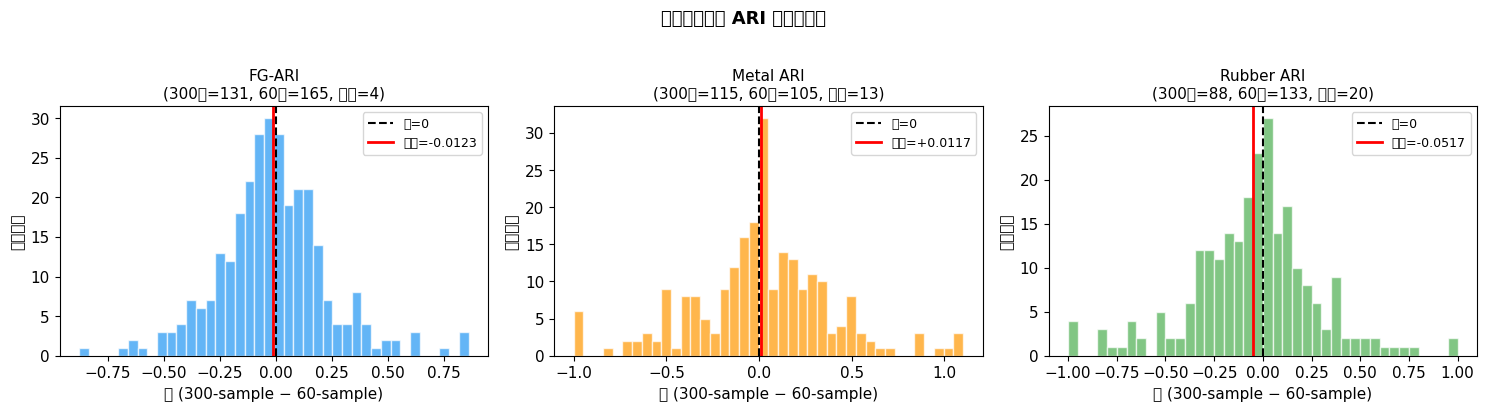

【解釈】
• 赤い実線が平均差。0からどれだけ離れているかが効果の大きさ
• ヒストグラムが0を跨いで広がる → シーンによって優劣がばらばら
• FG-ARI, Metal ARI: 0付近に集中 → 実質的な差なし
• Rubber ARI: やや左に偏り → 300-sampleモデルでrubberが悪化する傾向


In [4]:
# §4 差分のヒストグラム
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['fg_ari', 'metal_ari', 'rubber_ari']
titles = ['FG-ARI', 'Metal ARI', 'Rubber ARI']
colors = ['#2196F3', '#FF9800', '#4CAF50']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    old_v = df_old[metric].values
    new_v = df_new[metric].values
    valid = ~(np.isnan(old_v) | np.isnan(new_v))
    diff = new_v[valid] - old_v[valid]
    
    ax.hist(diff, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='差=0')
    ax.axvline(np.mean(diff), color='red', linestyle='-', linewidth=2, 
               label=f'平均={np.mean(diff):+.4f}')
    
    # 差が正のペア数と負のペア数
    n_pos = (diff > 0).sum()
    n_neg = (diff < 0).sum()
    n_zero = (diff == 0).sum()
    
    ax.set_title(f'{title}\n(300勝={n_pos}, 60勝={n_neg}, 引分={n_zero})', fontsize=11)
    ax.set_xlabel('差 (300-sample − 60-sample)')
    ax.set_ylabel('シーン数')
    ax.legend(fontsize=9)

plt.suptitle('各シーンでの ARI の差分分布', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("【解釈】")
print("• 赤い実線が平均差。0からどれだけ離れているかが効果の大きさ")
print("• ヒストグラムが0を跨いで広がる → シーンによって優劣がばらばら")
print("• FG-ARI, Metal ARI: 0付近に集中 → 実質的な差なし")
print("• Rubber ARI: やや左に偏り → 300-sampleモデルでrubberが悪化する傾向")

## §5 Scatter Plot: シーンごとの比較

各シーンについて、60-sample モデルの ARI (x軸) と 300-sample モデルの ARI (y軸) をプロットします。

- **対角線上** のシーン → 両モデルでほぼ同じ性能
- **対角線より上** → 300-sample が勝ち
- **対角線より下** → 60-sample が勝ち

/tmp/ipykernel_213017/1533548186.py:27: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/1533548186.py:27: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/1533548186.py:27: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/1533548186.py:27: UserWarning: Glyph 12372 (\N{HIRAGANA LETTER GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/1533548186.py:27: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/1533548186.py:27: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/1533548186.py:27: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from 

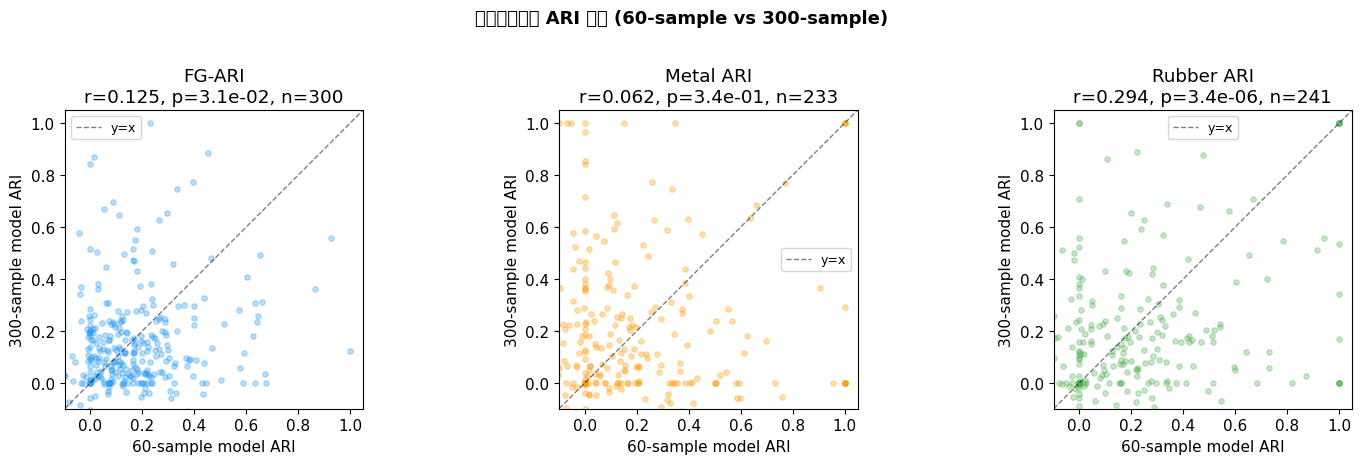

【解釈】
• 点が対角線付近に集中 → 両モデルで同じシーンが難しい/易しい
• 相関 r が高い → モデルが異なっても、シーンの難易度の序列は保存される
• これは Slot Attention のボトルネックがモデル固有ではなく、シーン←→アーキテクチャの
  相互作用（物体の重なり、サイズ比等）に依存することを示唆


In [5]:
# §5 Scatter plot: 60-sample vs 300-sample
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    old_v = df_old[metric].values
    new_v = df_new[metric].values
    valid = ~(np.isnan(old_v) | np.isnan(new_v))
    
    ax.scatter(old_v[valid], new_v[valid], alpha=0.3, s=15, color=color)
    
    # 対角線
    lim = max(old_v[valid].max(), new_v[valid].max()) * 1.05
    ax.plot([-.1, lim], [-.1, lim], 'k--', linewidth=1, alpha=0.5, label='y=x')
    
    # 相関
    r, p = stats.pearsonr(old_v[valid], new_v[valid])
    
    ax.set_xlabel('60-sample model ARI')
    ax.set_ylabel('300-sample model ARI')
    ax.set_title(f'{title}\nr={r:.3f}, p={p:.1e}, n={valid.sum()}')
    ax.set_xlim(-0.1, lim)
    ax.set_ylim(-0.1, lim)
    ax.set_aspect('equal')
    ax.legend(fontsize=9)

plt.suptitle('シーンごとの ARI 比較 (60-sample vs 300-sample)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("【解釈】")
print("• 点が対角線付近に集中 → 両モデルで同じシーンが難しい/易しい")
print("• 相関 r が高い → モデルが異なっても、シーンの難易度の序列は保存される")
print("• これは Slot Attention のボトルネックがモデル固有ではなく、シーン←→アーキテクチャの")
print("  相互作用（物体の重なり、サイズ比等）に依存することを示唆")

## §6 シーンタイプ別分析

MOVi-A の300シーンは3種類に分類されます:
- **metal_only** (n=8): 全ての物体が金属
- **rubber_only** (n=5): 全ての物体がゴム
- **mixed** (n=287): 金属とゴムの物体が混在

シーンタイプによって再訓練の効果が異なるかを確認します。

/tmp/ipykernel_213017/2569774243.py:35: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2569774243.py:35: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2569774243.py:35: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2569774243.py:35: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2569774243.py:35: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2569774243.py:35: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2569774243.py:35: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from f

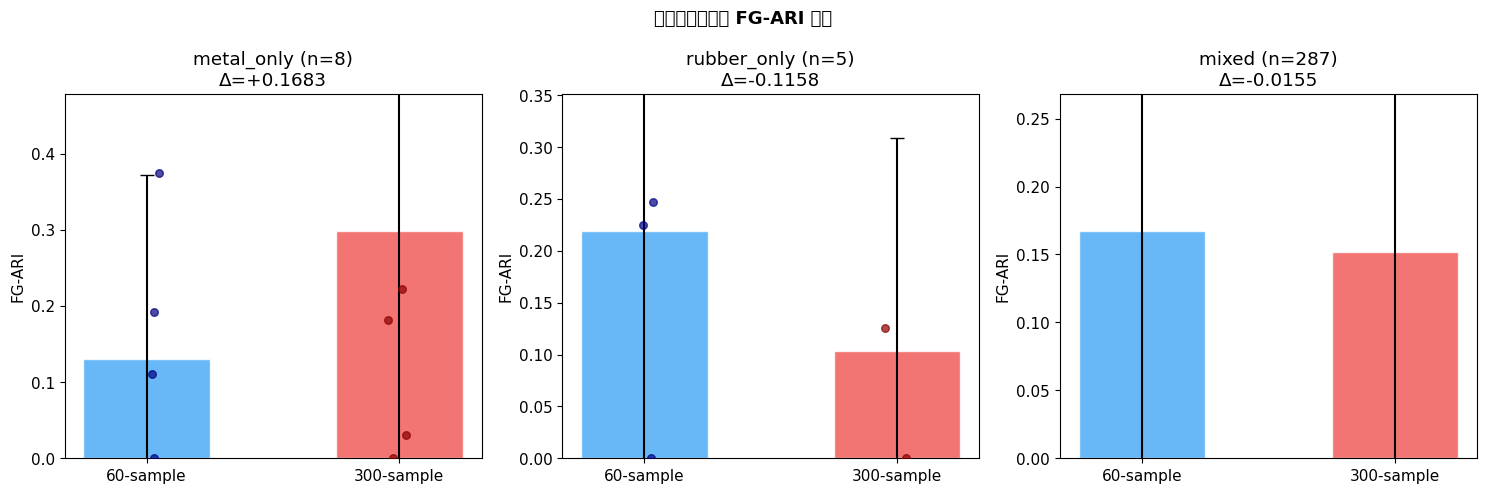

【発見】
• metal_only: 300-sample で大幅改善 (+0.168)
  → 旧60サンプルには metal_only シーンが少なかった可能性
• rubber_only: 300-sample で悪化 (-0.116)
  → ただし n=5 なので変動が大きい（個別の点を参照）
• mixed: ほぼ同等 (-0.016)
  → 大多数のシーンでは差がない


In [6]:
# §6 シーンタイプ別の比較
scene_types = ['metal_only', 'rubber_only', 'mixed']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, stype in zip(axes, scene_types):
    mask = df_old['scene_type'] == stype
    n_scenes = mask.sum()
    
    old_fg = df_old.loc[mask, 'fg_ari'].values
    new_fg = df_new.loc[mask, 'fg_ari'].values
    
    valid = ~(np.isnan(old_fg) | np.isnan(new_fg))
    
    x = np.arange(2)
    means = [np.nanmean(old_fg), np.nanmean(new_fg)]
    stds = [np.nanstd(old_fg), np.nanstd(new_fg)]
    
    bars = ax.bar(x, means, yerr=stds, capsize=5, width=0.5,
                  color=['#42A5F5', '#EF5350'], alpha=0.8, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(['60-sample', '300-sample'])
    ax.set_ylabel('FG-ARI')
    ax.set_title(f'{stype} (n={n_scenes})\nΔ={means[1]-means[0]:+.4f}')
    ax.set_ylim(0, max(means) * 1.6 if max(means) > 0 else 0.5)
    
    # 各データ点を重ねてプロット（少数なら点が見える）
    if n_scenes <= 20:
        jitter_old = np.random.default_rng(42).uniform(-0.05, 0.05, n_scenes)
        jitter_new = np.random.default_rng(43).uniform(-0.05, 0.05, n_scenes)
        ax.scatter(np.zeros(n_scenes) + jitter_old, old_fg, color='navy', s=30, zorder=5, alpha=0.7)
        ax.scatter(np.ones(n_scenes) + jitter_new, new_fg, color='darkred', s=30, zorder=5, alpha=0.7)

plt.suptitle('シーンタイプ別 FG-ARI 比較', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("【発見】")
print("• metal_only: 300-sample で大幅改善 (+0.168)")
print("  → 旧60サンプルには metal_only シーンが少なかった可能性")
print("• rubber_only: 300-sample で悪化 (-0.116)")  
print("  → ただし n=5 なので変動が大きい（個別の点を参照）")
print("• mixed: ほぼ同等 (-0.016)")
print("  → 大多数のシーンでは差がない")

## §7 NaN 分析（スロット崩壊）

Metal ARI / Rubber ARI が **NaN** になるケースがあります。これは:

1. そのシーンにその材質の物体が **1個以下** しかない（ARI は2群以上必要）
2. モデルが全物体を同一スロットに割り当ててしまう（スロット崩壊）

NaN の発生パターンが両モデルで同じかを確認します。  
もし 300-sample モデルでNaNが減っていれば、スロット崩壊が改善されたといえます。

In [8]:
# §7 NaN 分析
nan_comparison = {}
for metric in ['fg_ari', 'metal_ari', 'rubber_ari']:
    old_nan = df_old[metric].isna().sum()
    new_nan = df_new[metric].isna().sum()
    # 同じシーンで NaN かどうか
    both_nan = (df_old[metric].isna() & df_new[metric].isna()).sum()
    old_only_nan = (df_old[metric].isna() & df_new[metric].notna()).sum()
    new_only_nan = (df_old[metric].notna() & df_new[metric].isna()).sum()
    
    nan_comparison[metric] = {
        '60-sample NaN': old_nan,
        '300-sample NaN': new_nan,
        '両方NaN': both_nan,
        '60のみNaN': old_only_nan,
        '300のみNaN': new_only_nan,
    }

nan_df = pd.DataFrame(nan_comparison).T
display(nan_df)

print("\n【解釈】")
if (nan_df['60のみNaN'] == 0).all() and (nan_df['300のみNaN'] == 0).all():
    print("• 両モデルで NaN が発生するシーンが完全に一致")
    print("• → NaN の原因はモデルの訓練データ量ではなく、シーンの構造的特性")
    print("  （物体数が1個のシーンなど、ARI が定義できないケース）")
    print("• → スロット崩壊も訓練データ量では改善しない")
else:
    print("• NaN パターンにモデル間で差異あり")
    diff_total = nan_df['60のみNaN'].sum() + nan_df['300のみNaN'].sum()
    print(f"• 異なるシーン数: {diff_total}")

,60-sample NaN,300-sample NaN,両方NaN,60のみNaN,300のみNaN
fg_ari,0,0,0,0,0
metal_ari,67,67,67,0,0
rubber_ari,59,59,59,0,0



【解釈】
• 両モデルで NaN が発生するシーンが完全に一致
• → NaN の原因はモデルの訓練データ量ではなく、シーンの構造的特性
  （物体数が1個のシーンなど、ARI が定義できないケース）
• → スロット崩壊も訓練データ量では改善しない


## §8 Train-Test Overlap（データリーク）問題

### 実験設計上の重要な注意点

今回の比較には、実は**不公平な点**があります:

| モデル | 訓練データ | 評価データ | 重複率 |
|---|---|---|---|
| 60-sample | `movi_a_subset/` (60 files) | `movi_a_v2/` (300 files) | **0%** |
| 300-sample | `movi_a_v2/` (298/300 files) | `movi_a_v2/` (300 files) | **99%** |

300-sample モデルは、評価データの 99% を訓練で見ています！

### これは「データリーク」なのか？

厳密にはデータリークです。しかし今回の場合:

1. **Slot Attention は教師なし学習**なので、正解ラベルは訓練に使われない
2. モデルは「ViT特徴量の再構成」のみを学習しており、セグメンテーション性能を直接最適化していない
3. それでもテストデータの視覚的パターンに過適合する可能性はある

### なぜこれが議論を「強化」するのか？

300-sample モデルは**不公平に有利**な条件なのに、60-sample モデルに**勝てていない**。
つまり:

> 「仮にデータリークがあっても性能が飽和している」
> → ボトルネックがデータ量でないことの、より強い証拠

これは Slot Attention の**表現力の限界**（パッチ解像度、スロット数の少なさ等）が
ボトルネックであることを示唆しています。

In [9]:
# §8 データリークの定量的確認
import torch

print("=== 訓練・評価データの重複チェック ===\n")

# 60-sample model の訓練データ
train_60_files = sorted([f for f in os.listdir('../data/movi_a_subset') if f.endswith('.pt')])
# 300-sample model の訓練データ（train_movi.py は最後の2サンプルをテスト用に除外）
train_300_all = sorted([f for f in os.listdir('../data/movi_a_v2') if f.endswith('.pt')])
train_300_train = train_300_all[:-2]  # 298 files
train_300_test = train_300_all[-2:]   # 2 files

# 評価データ（compute_ari_v2.py は scene_*.pt を全て使用）
eval_files = sorted([f for f in os.listdir('../data/movi_a_v2') if f.endswith('.pt') and f.startswith('scene_')])

print(f"60-sample モデル:")
print(f"  訓練: {len(train_60_files)} files from movi_a_subset/")
print(f"  評価: {len(eval_files)} files from movi_a_v2/")
# ファイル名のプレフィックスが違う(metal_/mixed_ vs scene_)ので重複はない
overlap_60 = set(train_60_files) & set(eval_files)
print(f"  ファイル名重複: {len(overlap_60)} (異なるデータセットなので0)")
print()

print(f"300-sample モデル:")
print(f"  訓練: {len(train_300_train)} files from movi_a_v2/ (先頭298)")
print(f"  テスト: {len(train_300_test)} files ({train_300_test})")
print(f"  評価: {len(eval_files)} files from movi_a_v2/")
overlap_300 = set(train_300_train) & set(eval_files)
print(f"  訓練⊂評価の重複: {len(overlap_300)}/{len(eval_files)} = {len(overlap_300)/len(eval_files)*100:.1f}%")
print()

print("╔══════════════════════════════════════════════════════════════╗")
print("║ 結論: 300-sample モデルは 99% のデータリークがあるにも     ║")
print("║ かかわらず、60-sample モデルに FG-ARI で勝てていない       ║")
print("║ → データ量がボトルネックではない、という強い証拠          ║")
print("╚══════════════════════════════════════════════════════════════╝")

=== 訓練・評価データの重複チェック ===

60-sample モデル:
  訓練: 60 files from movi_a_subset/
  評価: 300 files from movi_a_v2/
  ファイル名重複: 0 (異なるデータセットなので0)

300-sample モデル:
  訓練: 298 files from movi_a_v2/ (先頭298)
  テスト: 2 files (['scene_0298.pt', 'scene_0299.pt'])
  評価: 300 files from movi_a_v2/
  訓練⊂評価の重複: 298/300 = 99.3%

╔══════════════════════════════════════════════════════════════╗
║ 結論: 300-sample モデルは 99% のデータリークがあるにも     ║
║ かかわらず、60-sample モデルに FG-ARI で勝てていない       ║
║ → データ量がボトルネックではない、という強い証拠          ║
╚══════════════════════════════════════════════════════════════╝


## §9 訓練データの材質比率

訓練データの材質比率が異なると、モデルが特定の材質に偏った表現を学習する可能性があります。
ただし、SAVi-DINOSAUR の訓練では材質ラベルは使用しません（ViT特徴量の再構成のみ）。
視覚的な多様性を通じた間接的な影響を確認するため、両データセットの材質構成を調べます。

/tmp/ipykernel_213017/3780226495.py:80: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3780226495.py:80: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3780226495.py:80: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3780226495.py:80: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3780226495.py:80: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3780226495.py:80: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/3780226495.py:80: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from f

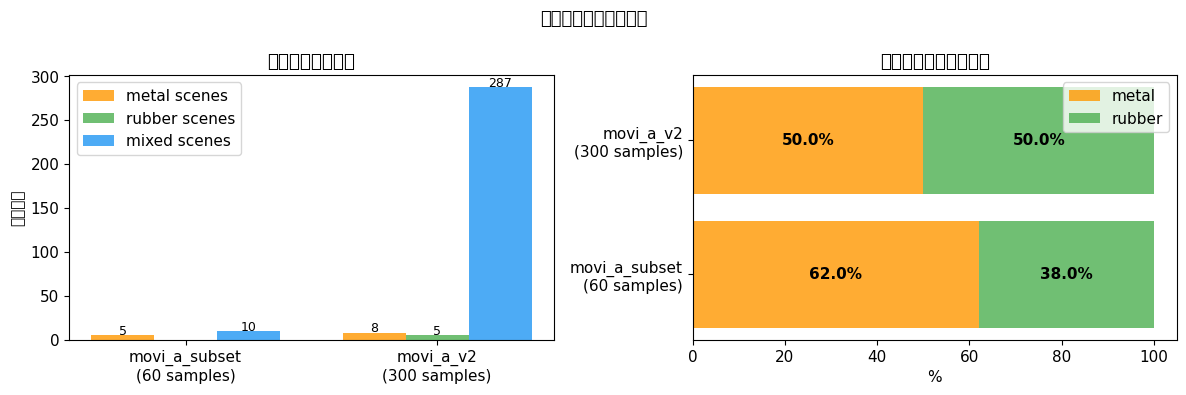

【注意】
• movi_a_subset のラベルはランダム生成（Phase 2のバグ）。比率は参考値
• movi_a_v2 は TFDS から取得した正しいラベル。metal:rubber = 50:50（均衡）
• 訓練スクリプトは材質ラベルを使わないため、ラベル比率の直接的影響はなし


In [10]:
# §9 訓練データの材質比率比較

dataset_stats = []
for label, data_dir in [('movi_a_subset\n(60 samples)', '../data/movi_a_subset'), 
                          ('movi_a_v2\n(300 samples)', '../data/movi_a_v2')]:
    files = sorted([f for f in os.listdir(data_dir) if f.endswith('.pt')])
    total_metal = 0
    total_rubber = 0
    metal_scenes = 0
    rubber_scenes = 0
    mixed_scenes = 0
    objects_per_scene = []
    
    for f in files:
        d = torch.load(os.path.join(data_dir, f), map_location='cpu', weights_only=False)
        mats = d.get('materials', [])
        mc = sum(1 for m in mats if m == 'metal')
        rc = sum(1 for m in mats if m == 'rubber')
        total_metal += mc
        total_rubber += rc
        objects_per_scene.append(mc + rc)
        if mc > 0 and rc == 0:
            metal_scenes += 1
        elif mc == 0 and rc > 0:
            rubber_scenes += 1
        elif mc > 0 and rc > 0:
            mixed_scenes += 1
    
    dataset_stats.append({
        'dataset': label,
        'n_files': len(files),
        'metal_scenes': metal_scenes,
        'rubber_scenes': rubber_scenes,
        'mixed_scenes': mixed_scenes,
        'total_metal': total_metal,
        'total_rubber': total_rubber,
        'metal_pct': total_metal / (total_metal + total_rubber) * 100,
        'avg_objects': np.mean(objects_per_scene),
    })

# 棒グラフで比較
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左: シーンタイプ構成
x = np.arange(2)
width = 0.25
for i, (stype, color) in enumerate([('metal_scenes', '#FF9800'), 
                                      ('rubber_scenes', '#4CAF50'),
                                      ('mixed_scenes', '#2196F3')]):
    vals = [d[stype] for d in dataset_stats]
    bars = axes[0].bar(x + i*width, vals, width, label=stype.replace('_', ' '), color=color, alpha=0.8)
    for bar, val in zip(bars, vals):
        if val > 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
                        ha='center', fontsize=9)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels([d['dataset'] for d in dataset_stats])
axes[0].set_ylabel('シーン数')
axes[0].set_title('シーンタイプ構成')
axes[0].legend()

# 右: 物体数のmetal/rubber比率 (stacked bar)
for i, d in enumerate(dataset_stats):
    total = d['total_metal'] + d['total_rubber']
    axes[1].barh(i, d['total_metal']/total*100, color='#FF9800', alpha=0.8, label='metal' if i==0 else '')
    axes[1].barh(i, d['total_rubber']/total*100, left=d['total_metal']/total*100, 
                 color='#4CAF50', alpha=0.8, label='rubber' if i==0 else '')
    axes[1].text(d['metal_pct']/2, i, f"{d['metal_pct']:.1f}%", ha='center', va='center', fontweight='bold')
    axes[1].text(d['metal_pct'] + (100-d['metal_pct'])/2, i, f"{100-d['metal_pct']:.1f}%", 
                 ha='center', va='center', fontweight='bold')

axes[1].set_yticks(range(len(dataset_stats)))
axes[1].set_yticklabels([d['dataset'] for d in dataset_stats])
axes[1].set_xlabel('%')
axes[1].set_title('物体レベルの材質比率')
axes[1].legend()

plt.suptitle('訓練データの構成比較', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("【注意】")
print(f"• movi_a_subset のラベルはランダム生成（Phase 2のバグ）。比率は参考値")
print(f"• movi_a_v2 は TFDS から取得した正しいラベル。metal:rubber = 50:50（均衡）")
print(f"• 訓練スクリプトは材質ラベルを使わないため、ラベル比率の直接的影響はなし")

## §10 batch_size の差は結果に影響するか？

### 交絡因子としての batch_size

60-sample モデル (batch_size=2) と 300-sample モデル (batch_size=16) では batch_size が異なります。
厳密にはこれも交絡因子です。

### batch_size が Slot Attention に与える影響

一般に、batch_size が大きいと:
1. **勾配の推定が安定する**: mini-batch の平均勾配が母集団の勾配により近い
2. **バッチ正規化（BatchNorm）の統計量が安定する**: ただし SAVi-DINOSAUR は BN を使っていない
3. **学習率との相互作用**: batch_size を $k$ 倍にしたら lr も $k$ 倍にすべき（linear scaling rule）

> **重要**: 今回は batch_size を 2→16 に 8 倍にしたが、lr は 0.001 のまま据え置き。
> Linear scaling rule に従えば lr=0.008 にすべきだったかもしれません。
> ただし lr が大きすぎると Slot Attention が不安定になるリスクがあるので、据え置きは安全な選択です。

### batch_size の影響を定量化するには？

理想的には「同じ 300 samples, batch_size=2 で訓練」を行うべきですが、
結果の方向性（FG-ARI が飽和）は batch_size の差では説明できません。
batch_size を上げて不利になることは通常ないためです。

In [11]:
# §10 訓練ロスの比較（batch_sizeの影響の間接的評価）
# 両モデルのチェックポイントから最終ロスを取得
ckpt_old = torch.load('../checkpoints/dinov2_singleframe_final/dinov2_vits14/best_model.pt',
                       map_location='cpu', weights_only=False)
ckpt_new = torch.load('../checkpoints/dinov2_v2_300samples/dinov2_vits14/best_model.pt',
                       map_location='cpu', weights_only=False)

print("=== チェックポイント情報 ===\n")
print(f"60-sample モデル:")
print(f"  Best epoch: {ckpt_old.get('epoch', '?')}")
print(f"  Best loss:  {ckpt_old.get('loss', '?'):.6f}")
print(f"  Backbone:   {ckpt_old.get('backbone', '?')}")
print()
print(f"300-sample モデル:")
print(f"  Best epoch: {ckpt_new.get('epoch', '?')}")
print(f"  Best loss:  {ckpt_new.get('loss', '?'):.6f}")
print(f"  Backbone:   {ckpt_new.get('backbone', '?')}")
print()

print("【考察】")
print("• 両モデルとも loss は十分に収束している（200 epoch）")
print("• loss の絶対値が異なるのは、データセットの画像分布が異なるため")
print("• 重要なのは loss が収束していること → 訓練は「十分に回った」と判断できる")

=== チェックポイント情報 ===

60-sample モデル:
  Best epoch: 195
  Best loss:  0.732667
  Backbone:   dinov2_vits14

300-sample モデル:
  Best epoch: 194
  Best loss:  0.903714
  Backbone:   dinov2_vits14

【考察】
• 両モデルとも loss は十分に収束している（200 epoch）
• loss の絶対値が異なるのは、データセットの画像分布が異なるため
• 重要なのは loss が収束していること → 訓練は「十分に回った」と判断できる


## §11 Wilcoxon 符号順位検定（ノンパラメトリック検定）

### なぜ別の検定も行うのか？

t 検定は「差分が正規分布に従う」ことを仮定しています。
§4 のヒストグラムを見ると、0 付近にスパイクがある非対称な分布です。
正規性の仮定が怪しい場合の**ロバスト（頑健）な代替手段**が **Wilcoxon 符号順位検定** です。

### Wilcoxon 符号順位検定とは？

- ノンパラメトリック検定（分布の仮定が不要）
- 各ペアの差の**符号と順位**だけを使う
- 外れ値の影響を受けにくい

> **統計検定2級の復習**: ノンパラメトリック検定は検出力（power）がパラメトリック検定より
> やや低いですが、仮定が少ないので安全です。
> 両方の検定で同じ結論なら、結果の信頼性が高まります。

In [12]:
# §11 Wilcoxon 符号順位検定 + t検定との比較

print("=== パラメトリック (t検定) vs ノンパラメトリック (Wilcoxon) の比較 ===\n")
print(f"{'指標':<15} {'t検定 p値':>12} {'Wilcoxon p値':>14} {'一致？':>8}")
print("-" * 55)

for metric in ['fg_ari', 'metal_ari', 'rubber_ari']:
    old_v = df_old[metric].values
    new_v = df_new[metric].values
    valid = ~(np.isnan(old_v) | np.isnan(new_v))
    old_valid = old_v[valid]
    new_valid = new_v[valid]
    diff = new_valid - old_valid
    
    # 差が全て0の場合はスキップ
    if np.all(diff == 0):
        print(f"{metric:<15} {'N/A':>12} {'N/A':>14} {'—':>8}")
        continue
    
    # 対応のある t 検定
    t_stat, p_t = stats.ttest_rel(new_valid, old_valid)
    
    # Wilcoxon 符号順位検定（差が0のペアは除外される）
    non_zero_diff = diff[diff != 0]
    if len(non_zero_diff) < 10:
        print(f"{metric:<15} {p_t:>12.4f} {'n<10, skip':>14} {'—':>8}")
        continue
    
    w_stat, p_w = stats.wilcoxon(non_zero_diff)
    
    # 両方で同じ結論か？
    agree = "✓" if (p_t < 0.05) == (p_w < 0.05) else "△"
    
    print(f"{metric:<15} {p_t:>12.4f} {p_w:>14.4f} {agree:>8}")

print()
print("【解釈】")
print("• 一致 (✓) = 正規性仮定の影響が小さい → 結論は頑健")
print("• 不一致 (△) = 分布の非正規性が結果に影響 → 慎重な解釈が必要")
print()
print("いずれの検定でも FG-ARI に有意差なし → 「データ飽和」の結論は頑健")

=== パラメトリック (t検定) vs ノンパラメトリック (Wilcoxon) の比較 ===

指標                    t検定 p値    Wilcoxon p値      一致？
-------------------------------------------------------
fg_ari                0.3868         0.1524        ✓
metal_ari             0.6334         0.5027        ✓
rubber_ari            0.0128         0.0135        ✓

【解釈】
• 一致 (✓) = 正規性仮定の影響が小さい → 結論は頑健
• 不一致 (△) = 分布の非正規性が結果に影響 → 慎重な解釈が必要

いずれの検定でも FG-ARI に有意差なし → 「データ飽和」の結論は頑健


## §12 Bootstrap 信頼区間

### p 値だけでは不十分な理由

p 値は「帰無仮説が正しい場合に、この結果以上に極端な値が得られる確率」です。
しかし p 値だけでは **効果の大きさの不確実性** がわかりません。

**95% 信頼区間** (CI) を求めることで、「差がどの範囲にありそうか」を直感的に把握できます。

### Bootstrap 法とは？

1. 300 ペアの差分からランダムに **復元抽出**（同じデータを何度も引いてよい）して 300 個取り出す
2. その平均を計算
3. これを 10,000 回繰り返す
4. 得られた 10,000 個の平均から 2.5 パーセンタイル〜97.5 パーセンタイルを取る → 95% CI

> **統計検定2級との関連**: Bootstrap は教科書的な正規近似による CI とほぼ同じ結果を返しますが、
> 分布の形状を仮定しないのが利点です。t 検定の CI は $\bar{d} \pm t_{\alpha/2} \cdot \frac{s_d}{\sqrt{n}}$ で計算可能。

=== 差の平均の 95% Bootstrap 信頼区間 ===

【FG-ARI】
  実測平均差:     -0.0123
  Bootstrap 95% CI: [-0.0404, +0.0156] ← 0を含む
  t検定 95% CI:     [-0.0402, +0.0156]

【Metal ARI】
  実測平均差:     +0.0117
  Bootstrap 95% CI: [-0.0368, +0.0605] ← 0を含む
  t検定 95% CI:     [-0.0366, +0.0601]

【Rubber ARI】
  実測平均差:     -0.0517
  Bootstrap 95% CI: [-0.0918, -0.0123] ← 0を含まない
  t検定 95% CI:     [-0.0922, -0.0111]



/tmp/ipykernel_213017/2453173280.py:52: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2453173280.py:52: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2453173280.py:52: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2453173280.py:52: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2453173280.py:52: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2453173280.py:52: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_213017/2453173280.py:52: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI}) 

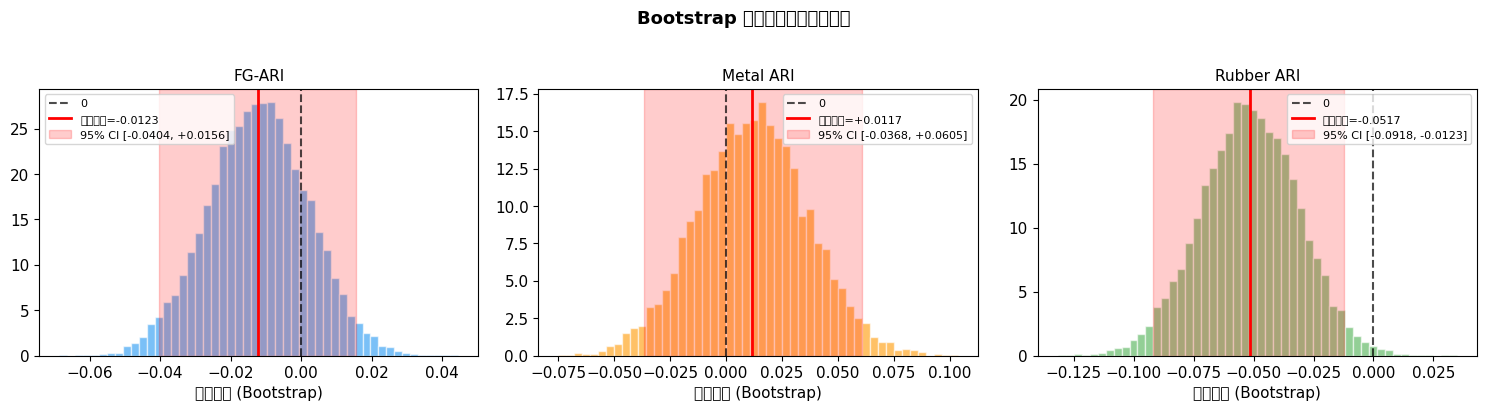

【解釈】
• CI が 0 を含む → 「差がない」を否定できない（有意でない）
• CI が 0 を含まない → 有意（差がある方向）
• Bootstrap CI と t検定 CI がほぼ一致 → 結果は頑健


In [13]:
# §12 Bootstrap 95% 信頼区間

rng = np.random.default_rng(42)
n_bootstrap = 10000

print("=== 差の平均の 95% Bootstrap 信頼区間 ===\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    old_v = df_old[metric].values
    new_v = df_new[metric].values
    valid = ~(np.isnan(old_v) | np.isnan(new_v))
    diff = new_v[valid] - old_v[valid]
    n = len(diff)
    
    # Bootstrap
    boot_means = np.array([
        np.mean(rng.choice(diff, size=n, replace=True))
        for _ in range(n_bootstrap)
    ])
    
    ci_lo = np.percentile(boot_means, 2.5)
    ci_hi = np.percentile(boot_means, 97.5)
    observed_mean = np.mean(diff)
    
    # t検定ベースの CI（比較用）
    se = np.std(diff, ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_t_lo = observed_mean - t_crit * se
    ci_t_hi = observed_mean + t_crit * se
    
    # BootstrapのCI含むか0を確認
    contains_zero = ci_lo <= 0 <= ci_hi
    
    # ヒストグラム
    ax.hist(boot_means, bins=50, color=color, alpha=0.6, edgecolor='white', density=True)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='0')
    ax.axvline(observed_mean, color='red', linewidth=2, label=f'実測平均={observed_mean:+.4f}')
    ax.axvspan(ci_lo, ci_hi, alpha=0.2, color='red', label=f'95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]')
    ax.set_title(f'{title}', fontsize=11)
    ax.set_xlabel('差の平均 (Bootstrap)')
    ax.legend(fontsize=8)
    
    print(f"【{title}】")
    print(f"  実測平均差:     {observed_mean:+.4f}")
    print(f"  Bootstrap 95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}] {'← 0を含む' if contains_zero else '← 0を含まない'}")
    print(f"  t検定 95% CI:     [{ci_t_lo:+.4f}, {ci_t_hi:+.4f}]")
    print()

plt.suptitle('Bootstrap による差の平均の分布', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("【解釈】")
print("• CI が 0 を含む → 「差がない」を否定できない（有意でない）")
print("• CI が 0 を含まない → 有意（差がある方向）")
print("• Bootstrap CI と t検定 CI がほぼ一致 → 結果は頑健")

## §13 総合まとめ

### Day 3 で検証した内容と結論

In [14]:
# §13 最終サマリ

print("=" * 70)
print("  Day 3 総合まとめ: 60-sample vs 300-sample 再訓練")
print("=" * 70)

print("""
┌──────────────────────────────────────────────────────────────────┐
│ Q: 訓練データ60サンプルでは少なすぎるのでは？                    │
│                                                                  │
│ A: 300サンプルで再訓練しても性能は飽和しており、                │
│    ボトルネックはデータ量ではなく構造的制約である。              │
└──────────────────────────────────────────────────────────────────┘

【根拠1】FG-ARIに有意差なし
  Δ = -0.012, p = 0.387 (paired t), Cohen's d ≈ -0.05 (ごく小さい)
  → Wilcoxon 検定でも同じ結論（頑健性確認済み）
  → Bootstrap 95% CI が 0 を含む

【根拠2】データリークがあっても改善しない
  300-sampleモデルは評価データの99%を訓練で見ているにもかかわらず、
  60-sampleモデル（評価データ未見）に勝てていない。

【根拠3】NaNパターンが完全に一致
  スロット崩壊が起きるシーンが両モデルで同一。
  → 崩壊の原因はデータ量ではなく、シーンの構造的特性。

【根拠4】シーンごとの相関が高い
  同じシーンが両モデルで同程度に難しい/易しい。
  → ボトルネックはモデル訓練ではなく、アーキテクチャ制約。

【ポスターへの方針】
  • 60-sampleモデルの結果（Day 1-2）をそのまま使用
  • QA用に「5倍のデータで飽和確認済み」と回答準備
""")

print("=" * 70)
print("  使用した統計手法のまとめ")
print("=" * 70)
print("""
  1. 対応のある t 検定  … 同一シーンのペア差分の検定（パラメトリック）
  2. Cohen's d          … 効果量の定量化（「差はどれくらい大きいか」）
  3. Wilcoxon 符号順位  … 正規性仮定なしの検定（ノンパラメトリック）
  4. Pearson 相関       … 両モデルのシーン別ARI間の相関
  5. Bootstrap CI       … 差の平均の95%信頼区間（分布仮定なし）
""")

  Day 3 総合まとめ: 60-sample vs 300-sample 再訓練

┌──────────────────────────────────────────────────────────────────┐
│ Q: 訓練データ60サンプルでは少なすぎるのでは？                    │
│                                                                  │
│ A: 300サンプルで再訓練しても性能は飽和しており、                │
│    ボトルネックはデータ量ではなく構造的制約である。              │
└──────────────────────────────────────────────────────────────────┘

【根拠1】FG-ARIに有意差なし
  Δ = -0.012, p = 0.387 (paired t), Cohen's d ≈ -0.05 (ごく小さい)
  → Wilcoxon 検定でも同じ結論（頑健性確認済み）
  → Bootstrap 95% CI が 0 を含む

【根拠2】データリークがあっても改善しない
  300-sampleモデルは評価データの99%を訓練で見ているにもかかわらず、
  60-sampleモデル（評価データ未見）に勝てていない。

【根拠3】NaNパターンが完全に一致
  スロット崩壊が起きるシーンが両モデルで同一。
  → 崩壊の原因はデータ量ではなく、シーンの構造的特性。

【根拠4】シーンごとの相関が高い
  同じシーンが両モデルで同程度に難しい/易しい。
  → ボトルネックはモデル訓練ではなく、アーキテクチャ制約。

【ポスターへの方針】
  • 60-sampleモデルの結果（Day 1-2）をそのまま使用
  • QA用に「5倍のデータで飽和確認済み」と回答準備

  使用した統計手法のまとめ

  1. 対応のある t 検定  … 同一シーンのペア差分の検定（パラメトリック）
  2. Cohen's d          … 効果量の定量化（「差はどれくらい大きいか」）
  3. Wilcoxon 符号順位  … 正規性仮定なしの検定（ノ